# NB02: Fitness Cost Analysis

Core analysis testing H1: AMR gene knockouts show positive fitness under non-antibiotic conditions.

**Steps:**
1. Spot-check unclassified Tier 2 genes for false positives
2. Quantify essential AMR gene fraction vs background
3. Compute per-gene mean fitness across non-antibiotic experiments
4. Sensitivity analysis: Tier 1 only vs Tier 1+2
5. Per-organism Mann-Whitney U tests (BH-FDR)
6. Pan-bacterial random-effects meta-analysis (DerSimonian-Laird)
7. Exploratory plots

**Inputs:** `data/amr_genes_fb.csv`, `data/experiment_classification.csv`, fitness matrices from `fitness_modules`

**Outputs:** `data/amr_fitness_noabx.csv`, `data/organism_effect_sizes.csv`, figures

In [1]:
import os
import warnings
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

# Paths
_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_fitness_cost')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_fitness_cost')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
FM_DATA = os.path.join(REPO, 'projects', 'fitness_modules', 'data')
EG_DATA = os.path.join(REPO, 'projects', 'essential_genome', 'data')

os.makedirs(FIGURES, exist_ok=True)

# Load data
amr = pd.read_csv(os.path.join(DATA, 'amr_genes_fb.csv'))
exps = pd.read_csv(os.path.join(DATA, 'experiment_classification.csv'))

print(f'AMR genes: {len(amr)}')
print(f'Experiments: {len(exps)}')
print(f'Organisms with AMR: {amr["orgId"].nunique()}')

AMR genes: 1352
Experiments: 6804
Organisms with AMR: 43


## 1. Spot-check unclassified Tier 2 genes

In [2]:
# Examine the 114 unclassified Tier 2 genes
unclassified = amr[(amr['amr_tier'] == 2) & (amr['amr_class'] == 'unclassified')]
print(f'Unclassified Tier 2 genes: {len(unclassified)}')
print(f'\nSample of 20 product annotations:')
sample = unclassified.sample(min(20, len(unclassified)), random_state=42)
for _, row in sample.iterrows():
    print(f"  {row['orgId']:20s} {row['locusId']:>10s}  {row['amr_product']}")

# Count unique product descriptions
print(f'\nAll unique product annotations ({unclassified["amr_product"].nunique()} unique):')
for prod, cnt in unclassified['amr_product'].value_counts().items():
    print(f'  {cnt:3d}x  {prod}')

Unclassified Tier 2 genes: 114

Sample of 20 product annotations:
  WCS417                   GFF205  RND efflux pump membrane fusion protein barrel-sandwich domain-containing protein
  BFirm                BPHYT_RS07110  Fosfomycin resistance protein AbaF
  Koxy                 BWI76_RS10855  RND efflux pump membrane fusion protein barrel-sandwich domain-containing protein
  RalstoniaUW163       UW163_RS15265  Rnd efflux pump, membrane fusion protein, czcb subfamily
  BFirm                BPHYT_RS30290  Fosfomycin resistance protein AbaF
  MR1                      202386  RND superfamily efflux pump MFP component
  RalstoniaUW163       UW163_RS21865  Rnd efflux pump, membrane fusion protein, czcb subfamily
  RalstoniaBSBF1503    RALBFv3_RS17280  Rnd efflux pump, membrane fusion protein, czcb subfamily
  Marino                  GFF3881  Drug resistance transporter, EmrB/QacA family
  Btheta                   350483  RND efflux pump membrane fusion protein barrel-sandwich domain-containi

In [3]:
# Decision: flag likely false positives
# Products that are clearly AMR-related should stay; others are suspect
# We'll keep unclassified in the Tier 1+2 pool but flag them,
# and rely on the Tier 1-only sensitivity analysis to assess impact.

amr['is_unclassified_t2'] = (amr['amr_tier'] == 2) & (amr['amr_class'] == 'unclassified')
print(f'Flagged as unclassified Tier 2: {amr["is_unclassified_t2"].sum()}')
print(f'Clean AMR genes (classified): {(~amr["is_unclassified_t2"]).sum()}')

Flagged as unclassified Tier 2: 114
Clean AMR genes (classified): 1238


## 2. Essential gene quantification

AMR genes absent from genefitness (putatively essential) are invisible to this analysis.
Quantify the fraction and compare to background.

In [4]:
# For each organism with a fitness matrix, check which AMR genes are present
matrix_files = sorted(glob(os.path.join(FM_DATA, 'matrices', '*_fitness_matrix.csv')))
matrix_orgs = {os.path.basename(f).replace('_fitness_matrix.csv', '') for f in matrix_files}

# Organisms qualifying for per-organism tests (>=5 AMR genes + fitness matrix)
amr_per_org = amr.groupby('orgId').size()
qualifying_orgs = sorted(set(amr_per_org[amr_per_org >= 5].index) & matrix_orgs)
small_orgs = sorted(set(amr_per_org[amr_per_org < 5].index) & matrix_orgs)

print(f'Qualifying organisms (>=5 AMR genes + matrix): {len(qualifying_orgs)}')
print(f'Small organisms (<5 AMR genes, supplementary): {len(small_orgs)}: {small_orgs}')

essential_stats = []
for org in qualifying_orgs + small_orgs:
    mat_path = os.path.join(FM_DATA, 'matrices', f'{org}_fitness_matrix.csv')
    if not os.path.exists(mat_path):
        continue
    fit_mat = pd.read_csv(mat_path, index_col=0, nrows=0)  # just get index
    fit_loci = set(str(l) for l in pd.read_csv(mat_path, usecols=[0]).iloc[:, 0])
    
    org_amr = amr[amr['orgId'] == org]
    amr_loci = set(str(l) for l in org_amr['locusId'])
    amr_in_matrix = amr_loci & fit_loci
    amr_missing = amr_loci - fit_loci
    
    # Background: total genes in matrix vs total CDS genes
    # (genes in matrix = have fitness data; genes NOT in matrix = putatively essential)
    total_in_matrix = len(fit_loci)
    
    essential_stats.append({
        'orgId': org,
        'n_amr': len(amr_loci),
        'n_amr_in_matrix': len(amr_in_matrix),
        'n_amr_missing': len(amr_missing),
        'pct_amr_missing': len(amr_missing) / len(amr_loci) * 100 if amr_loci else 0,
        'n_total_in_matrix': total_in_matrix,
    })

ess_df = pd.DataFrame(essential_stats)
print(f'\nEssential gene (missing from matrix) rates:')
print(f'  AMR genes missing: {ess_df["n_amr_missing"].sum()} / {ess_df["n_amr"].sum()} '
      f'({ess_df["n_amr_missing"].sum() / ess_df["n_amr"].sum() * 100:.1f}%)')
print(f'\nPer-organism:')
for _, row in ess_df.iterrows():
    print(f'  {row["orgId"]:25s}  {row["n_amr_missing"]:2.0f}/{row["n_amr"]:3.0f} missing '
          f'({row["pct_amr_missing"]:5.1f}%)')

Qualifying organisms (>=5 AMR genes + matrix): 25
Small organisms (<5 AMR genes, supplementary): 3: ['Methanococcus_JJ', 'Methanococcus_S2', 'Pedo557']



Essential gene (missing from matrix) rates:
  AMR genes missing: 39 / 840 (4.6%)

Per-organism:
  ANA3                        2/ 48 missing (  4.2%)
  BFirm                       3/ 53 missing (  5.7%)
  Btheta                      2/ 32 missing (  6.2%)
  Caulo                       0/ 35 missing (  0.0%)
  Cup4G11                     1/ 78 missing (  1.3%)
  Dino                        1/ 31 missing (  3.2%)
  DvH                         1/ 18 missing (  5.6%)
  Keio                        1/  9 missing ( 11.1%)
  Korea                       0/ 36 missing (  0.0%)
  Koxy                        1/ 48 missing (  2.1%)
  MR1                         0/ 22 missing (  0.0%)
  Marino                      0/ 22 missing (  0.0%)
  PV4                         0/ 21 missing (  0.0%)
  Phaeo                       0/ 17 missing (  0.0%)
  Ponti                       0/ 32 missing (  0.0%)
  Putida                      1/ 48 missing (  2.1%)
  SynE                        0/ 11 missing (  0.0%)
  

## 3. Compute per-gene mean fitness under non-antibiotic conditions

In [5]:
# For each organism: load fitness matrix, compute per-gene mean fitness
# across standard + carbon/nitrogen experiments

all_gene_fitness = []  # per-gene results
org_summaries = []     # per-organism summaries

for org in qualifying_orgs + small_orgs:
    mat_path = os.path.join(FM_DATA, 'matrices', f'{org}_fitness_matrix.csv')
    if not os.path.exists(mat_path):
        continue
    
    # Load fitness matrix
    fit_mat = pd.read_csv(mat_path, index_col=0)
    fit_mat.index = fit_mat.index.astype(str)
    # Ensure numeric (pitfall: FB values sometimes stored as strings)
    fit_mat = fit_mat.apply(pd.to_numeric, errors='coerce')
    
    # Select non-antibiotic experiments for this organism
    org_exps = exps[exps['orgId'] == org]
    non_abx_exp_names = org_exps[
        org_exps['exp_category'].isin(['standard', 'carbon_nitrogen'])
    ]['expName'].tolist()
    
    # Intersect with available columns in the matrix
    available_exps = [e for e in non_abx_exp_names if e in fit_mat.columns]
    if len(available_exps) == 0:
        print(f'  {org}: no non-antibiotic experiments in matrix, skipping')
        continue
    
    fit_sub = fit_mat[available_exps]
    
    # Identify AMR and non-AMR genes in matrix
    org_amr = amr[amr['orgId'] == org]
    amr_loci = set(str(l) for l in org_amr['locusId'])
    amr_in_mat = sorted(amr_loci & set(fit_sub.index))
    non_amr_in_mat = sorted(set(fit_sub.index) - amr_loci)
    
    if len(amr_in_mat) == 0:
        continue
    
    # Per-gene mean fitness across non-antibiotic experiments
    amr_mean = fit_sub.loc[amr_in_mat].mean(axis=1)
    bg_mean = fit_sub.loc[non_amr_in_mat].mean(axis=1)
    
    # Store per-gene results
    for locus in amr_in_mat:
        gene_info = org_amr[org_amr['locusId'].astype(str) == locus].iloc[0]
        all_gene_fitness.append({
            'orgId': org,
            'locusId': locus,
            'mean_fitness': amr_mean[locus],
            'amr_class': gene_info['amr_class'],
            'amr_mechanism': gene_info['amr_mechanism'],
            'resistance_type': gene_info['resistance_type'],
            'is_core': gene_info['is_core'],
            'intrinsic_proxy': gene_info['intrinsic_proxy'],
            'amr_tier': gene_info['amr_tier'],
            'amr_gene': gene_info.get('amr_gene', ''),
            'is_unclassified_t2': gene_info.get('amr_class') == 'unclassified' and gene_info['amr_tier'] == 2,
            'n_experiments': len(available_exps),
        })
    
    # Per-organism summary
    org_summaries.append({
        'orgId': org,
        'n_amr_in_mat': len(amr_in_mat),
        'n_non_amr': len(non_amr_in_mat),
        'n_exps': len(available_exps),
        'amr_mean_fitness': amr_mean.mean(),
        'amr_median_fitness': amr_mean.median(),
        'bg_mean_fitness': bg_mean.mean(),
        'bg_median_fitness': bg_mean.median(),
        'qualifying': org in qualifying_orgs,
    })

gene_df = pd.DataFrame(all_gene_fitness)
org_df = pd.DataFrame(org_summaries)

print(f'Per-gene fitness computed for {len(gene_df)} AMR genes across {len(org_df)} organisms')
print(f'Qualifying for per-organism tests: {org_df["qualifying"].sum()}')
print(f'\nOverall AMR mean fitness: {gene_df["mean_fitness"].mean():.4f} '
      f'(median: {gene_df["mean_fitness"].median():.4f})')

Per-gene fitness computed for 801 AMR genes across 28 organisms
Qualifying for per-organism tests: 25

Overall AMR mean fitness: -0.0237 (median: -0.0014)


In [6]:
# Quick summary table
print(f'{"Organism":25s} {"N_AMR":>5s} {"N_bg":>6s} {"N_exp":>5s} '
      f'{"AMR_mean":>8s} {"BG_mean":>8s} {"Shift":>8s}')
print('-' * 75)
for _, row in org_df.sort_values('n_amr_in_mat', ascending=False).iterrows():
    shift = row['amr_mean_fitness'] - row['bg_mean_fitness']
    qual = '*' if row['qualifying'] else ' '
    print(f'{qual}{row["orgId"]:24s} {row["n_amr_in_mat"]:5.0f} {row["n_non_amr"]:6.0f} '
          f'{row["n_exps"]:5.0f} {row["amr_mean_fitness"]:+8.4f} '
          f'{row["bg_mean_fitness"]:+8.4f} {shift:+8.4f}')
print('\n* = qualifying for per-organism tests (>=5 AMR genes)')

Organism                  N_AMR   N_bg N_exp AMR_mean  BG_mean    Shift
---------------------------------------------------------------------------
*Cup4G11                     77   6307    72  -0.0065  -0.0736  +0.0671
*BFirm                       50   5378    91  -0.0162  -0.0961  +0.0799
*Koxy                        47   4561   163  +0.0190  -0.1225  +0.1415
*Putida                      47   4731   260  -0.0082  -0.0802  +0.0720
*ANA3                        46   3622    58  -0.0699  -0.2155  +0.1456
*pseudo13_GW456_L13          38   4312    78  -0.0655  -0.1428  +0.0773
*Korea                       36   3357    70  -0.0396  -0.1424  +0.1027
*Caulo                       35   3277   103  -0.0786  -0.1117  +0.0331
*Ponti                       32   3653    10  -0.0111  -0.0808  +0.0697
*WCS417                      32   4387   128  +0.0015  -0.0783  +0.0798
*pseudo6_N2E2                32   5101   128  +0.0044  -0.0812  +0.0857
*Btheta                      30   4025   160  -0.0288  -0.12

## 4. Sensitivity analysis: Tier 1 only vs Tier 1+2

In [7]:
# Compare mean fitness distribution: Tier 1 only vs all
tier1_genes = gene_df[gene_df['amr_tier'] == 1]
tier2_genes = gene_df[gene_df['amr_tier'] == 2]
classified_genes = gene_df[~gene_df['is_unclassified_t2']]

print('Sensitivity analysis: Tier 1 vs Tier 1+2 vs Classified only')
print(f'  Tier 1 only:     N={len(tier1_genes):4d}  mean={tier1_genes["mean_fitness"].mean():+.4f}  '
      f'median={tier1_genes["mean_fitness"].median():+.4f}')
print(f'  Tier 2 only:     N={len(tier2_genes):4d}  mean={tier2_genes["mean_fitness"].mean():+.4f}  '
      f'median={tier2_genes["mean_fitness"].median():+.4f}')
print(f'  Classified only: N={len(classified_genes):4d}  mean={classified_genes["mean_fitness"].mean():+.4f}  '
      f'median={classified_genes["mean_fitness"].median():+.4f}')
print(f'  All (T1+T2):     N={len(gene_df):4d}  mean={gene_df["mean_fitness"].mean():+.4f}  '
      f'median={gene_df["mean_fitness"].median():+.4f}')

# Kolmogorov-Smirnov: are T1 and T2 distributions different?
if len(tier1_genes) >= 5 and len(tier2_genes) >= 5:
    ks_stat, ks_p = stats.ks_2samp(tier1_genes['mean_fitness'], tier2_genes['mean_fitness'])
    print(f'\n  KS test (Tier 1 vs Tier 2): D={ks_stat:.3f}, p={ks_p:.4g}')

# One-sample tests: is AMR fitness > 0? (cost = positive fitness of knockout)
for label, subset in [('Tier 1 only', tier1_genes), ('All T1+T2', gene_df),
                       ('Classified', classified_genes)]:
    if len(subset) < 5:
        continue
    wilcox_stat, wilcox_p = stats.wilcoxon(subset['mean_fitness'], alternative='greater')
    print(f'  Wilcoxon signed-rank (H1: fitness > 0) [{label}]: '
          f'p={wilcox_p:.4g}, median={subset["mean_fitness"].median():+.4f}')

Sensitivity analysis: Tier 1 vs Tier 1+2 vs Classified only
  Tier 1 only:     N= 110  mean=-0.0194  median=+0.0086
  Tier 2 only:     N= 691  mean=-0.0243  median=-0.0027
  Classified only: N= 727  mean=-0.0244  median=-0.0015
  All (T1+T2):     N= 801  mean=-0.0237  median=-0.0014

  KS test (Tier 1 vs Tier 2): D=0.112, p=0.1735
  Wilcoxon signed-rank (H1: fitness > 0) [Tier 1 only]: p=0.5551, median=+0.0086
  Wilcoxon signed-rank (H1: fitness > 0) [All T1+T2]: p=0.9985, median=-0.0014
  Wilcoxon signed-rank (H1: fitness > 0) [Classified]: p=0.9986, median=-0.0015


## 5. Per-organism Mann-Whitney U tests

In [8]:
# For each qualifying organism, test whether AMR genes have higher mean fitness
# than non-AMR background genes (Mann-Whitney U, one-sided)

mw_results = []

for org in qualifying_orgs:
    mat_path = os.path.join(FM_DATA, 'matrices', f'{org}_fitness_matrix.csv')
    fit_mat = pd.read_csv(mat_path, index_col=0)
    fit_mat.index = fit_mat.index.astype(str)
    fit_mat = fit_mat.apply(pd.to_numeric, errors='coerce')
    
    org_exps = exps[exps['orgId'] == org]
    non_abx_exp_names = org_exps[
        org_exps['exp_category'].isin(['standard', 'carbon_nitrogen'])
    ]['expName'].tolist()
    available_exps = [e for e in non_abx_exp_names if e in fit_mat.columns]
    if not available_exps:
        continue
    
    fit_sub = fit_mat[available_exps]
    
    org_amr = amr[amr['orgId'] == org]
    amr_loci = set(str(l) for l in org_amr['locusId'])
    amr_in_mat = sorted(amr_loci & set(fit_sub.index))
    non_amr_in_mat = sorted(set(fit_sub.index) - amr_loci)
    
    if len(amr_in_mat) < 5:
        continue
    
    amr_means = fit_sub.loc[amr_in_mat].mean(axis=1)
    bg_means = fit_sub.loc[non_amr_in_mat].mean(axis=1)
    
    # Mann-Whitney U: AMR > background (one-sided)
    u_stat, p_val = stats.mannwhitneyu(amr_means, bg_means, alternative='greater')
    
    # Effect size: difference in means and Cohen's d
    diff = amr_means.mean() - bg_means.mean()
    pooled_std = np.sqrt((amr_means.var() * (len(amr_means) - 1) + 
                          bg_means.var() * (len(bg_means) - 1)) /
                         (len(amr_means) + len(bg_means) - 2))
    cohens_d = diff / pooled_std if pooled_std > 0 else 0
    
    # Standard error of the mean difference (for meta-analysis)
    se_diff = np.sqrt(amr_means.var() / len(amr_means) + bg_means.var() / len(bg_means))
    
    mw_results.append({
        'orgId': org,
        'n_amr': len(amr_in_mat),
        'n_bg': len(non_amr_in_mat),
        'n_exps': len(available_exps),
        'amr_mean': amr_means.mean(),
        'bg_mean': bg_means.mean(),
        'diff': diff,
        'se_diff': se_diff,
        'cohens_d': cohens_d,
        'U': u_stat,
        'p_value': p_val,
    })

mw_df = pd.DataFrame(mw_results)

# BH-FDR correction
from statsmodels.stats.multitest import multipletests
reject, q_values, _, _ = multipletests(mw_df['p_value'], method='fdr_bh')
mw_df['q_value'] = q_values
mw_df['significant'] = reject

print(f'Per-organism Mann-Whitney U (H1: AMR fitness > background):')
print(f'  Tested: {len(mw_df)} organisms')
print(f'  Nominally significant (p<0.05): {(mw_df["p_value"] < 0.05).sum()}')
print(f'  FDR significant (q<0.05): {mw_df["significant"].sum()}')
print(f'  Positive shift (AMR > bg): {(mw_df["diff"] > 0).sum()}/{len(mw_df)}')
print(f'\nMedian effect size (diff): {mw_df["diff"].median():+.4f}')
print(f'Median Cohen\'s d: {mw_df["cohens_d"].median():+.4f}')

print(f'\n{"Organism":25s} {"N_AMR":>5s} {"Diff":>8s} {"d":>6s} {"p":>8s} {"q":>8s} {"Sig":>4s}')
print('-' * 70)
for _, row in mw_df.sort_values('p_value').iterrows():
    sig = '***' if row['q_value'] < 0.001 else '**' if row['q_value'] < 0.01 else '*' if row['q_value'] < 0.05 else ''
    print(f'{row["orgId"]:25s} {row["n_amr"]:5.0f} {row["diff"]:+8.4f} '
          f'{row["cohens_d"]:+6.3f} {row["p_value"]:8.4g} {row["q_value"]:8.4g} {sig:>4s}')

Per-organism Mann-Whitney U (H1: AMR fitness > background):
  Tested: 25 organisms
  Nominally significant (p<0.05): 6
  FDR significant (q<0.05): 2
  Positive shift (AMR > bg): 25/25

Median effect size (diff): +0.0798
Median Cohen's d: +0.1847

Organism                  N_AMR     Diff      d        p        q  Sig
----------------------------------------------------------------------
acidovorax_3H11              28  +0.1233 +0.324 0.001195  0.01935    *
Koxy                         47  +0.1415 +0.238 0.001548  0.01935    *
pseudo6_N2E2                 32  +0.0857 +0.201  0.01039  0.08656     
psRCH2                       30  +0.0780 +0.167  0.02737   0.1711     
Putida                       47  +0.0720 +0.177  0.03688   0.1844     
WCS417                       32  +0.0798 +0.182  0.04614   0.1923     
Cup4G11                      77  +0.0671 +0.185  0.05794   0.2069     
Ponti                        32  +0.0697 +0.210    0.105   0.2887     
pseudo5_N2C3_1               30  +0.0866 +0

## 6. Random-effects meta-analysis (DerSimonian-Laird)

In [9]:
def dersimonian_laird(effects, se):
    """Random-effects meta-analysis using DerSimonian-Laird method.
    
    Parameters
    ----------
    effects : array-like, per-study effect sizes
    se : array-like, per-study standard errors
    
    Returns
    -------
    dict with pooled effect, CI, tau2, I2, Q, p_Q, z, p_z
    """
    effects = np.asarray(effects, dtype=float)
    se = np.asarray(se, dtype=float)
    k = len(effects)
    
    # Fixed-effects weights
    w_fe = 1.0 / se**2
    
    # Fixed-effects pooled estimate
    theta_fe = np.sum(w_fe * effects) / np.sum(w_fe)
    
    # Cochran's Q
    Q = np.sum(w_fe * (effects - theta_fe)**2)
    df = k - 1
    p_Q = 1 - stats.chi2.cdf(Q, df) if df > 0 else 1.0
    
    # Between-study variance (tau^2)
    C = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0, (Q - df) / C) if C > 0 else 0
    
    # Random-effects weights
    w_re = 1.0 / (se**2 + tau2)
    
    # Random-effects pooled estimate
    theta_re = np.sum(w_re * effects) / np.sum(w_re)
    se_re = np.sqrt(1.0 / np.sum(w_re))
    
    # CI and test
    ci_lo = theta_re - 1.96 * se_re
    ci_hi = theta_re + 1.96 * se_re
    z = theta_re / se_re
    p_z = 1 - stats.norm.cdf(z)  # one-sided: effect > 0
    
    # I^2
    I2 = max(0, (Q - df) / Q * 100) if Q > 0 else 0
    
    return {
        'theta': theta_re, 'se': se_re,
        'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'z': z, 'p_z': p_z,
        'tau2': tau2, 'I2': I2,
        'Q': Q, 'p_Q': p_Q, 'k': k,
    }


# Run meta-analysis on qualifying organisms
meta = dersimonian_laird(mw_df['diff'].values, mw_df['se_diff'].values)

print('=== Pan-Bacterial Random-Effects Meta-Analysis (DerSimonian-Laird) ===')
print(f'  Studies (organisms): {meta["k"]}')
print(f'  Pooled effect (AMR - background fitness): {meta["theta"]:+.4f}')
print(f'  95% CI: [{meta["ci_lo"]:+.4f}, {meta["ci_hi"]:+.4f}]')
print(f'  z = {meta["z"]:.3f}, p = {meta["p_z"]:.4g} (one-sided: effect > 0)')
print(f'  Between-study heterogeneity: tau² = {meta["tau2"]:.6f}, I² = {meta["I2"]:.1f}%')
print(f'  Cochran\'s Q = {meta["Q"]:.2f}, p = {meta["p_Q"]:.4g}')

if meta['ci_lo'] > 0:
    print('\n  >> H1 SUPPORTED: AMR gene knockouts show significantly positive fitness')
    print('     (resistance genes impose a cost under non-antibiotic conditions)')
elif meta['ci_hi'] < 0:
    print('\n  >> UNEXPECTED: AMR gene knockouts show significantly negative fitness')
    print('     (resistance genes appear beneficial even without antibiotics)')
else:
    print('\n  >> H0 NOT REJECTED: 95% CI includes zero')
    print('     (no detectable pan-bacterial cost of resistance)')

=== Pan-Bacterial Random-Effects Meta-Analysis (DerSimonian-Laird) ===
  Studies (organisms): 25
  Pooled effect (AMR - background fitness): +0.0860
  95% CI: [+0.0742, +0.0978]
  z = 14.276, p = 0 (one-sided: effect > 0)
  Between-study heterogeneity: tau² = 0.000432, I² = 54.3%
  Cochran's Q = 52.54, p = 0.0006644

  >> H1 SUPPORTED: AMR gene knockouts show significantly positive fitness
     (resistance genes impose a cost under non-antibiotic conditions)


## 7. Exploratory plots

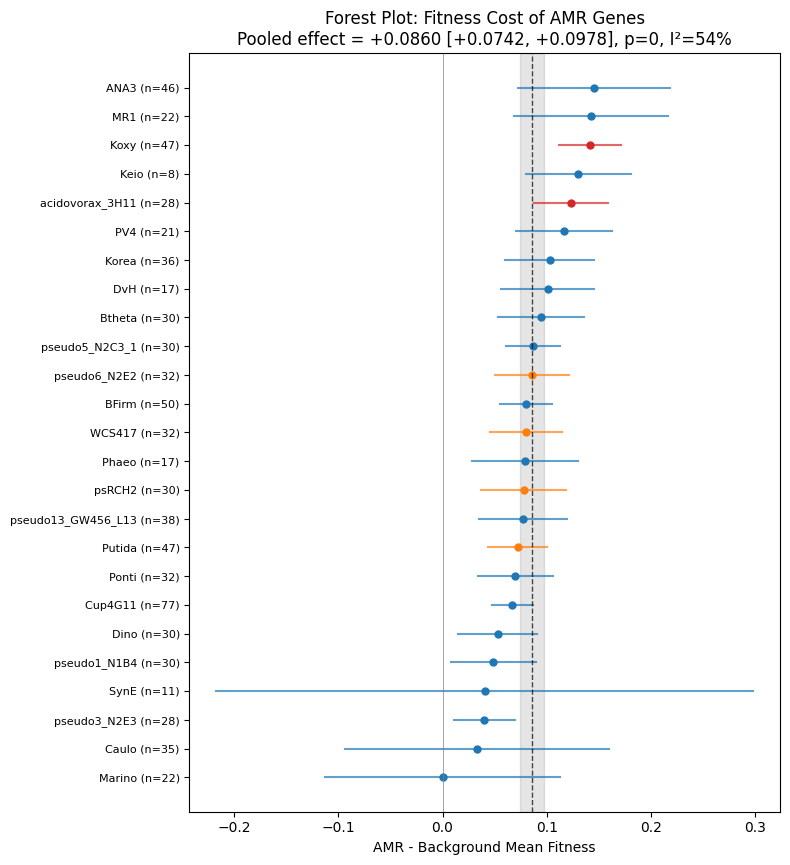

Saved to figures/forest_plot_amr_fitness.png


In [10]:
# Forest plot: per-organism effect sizes with CIs
fig, ax = plt.subplots(figsize=(8, max(6, len(mw_df) * 0.35)))

plot_df = mw_df.sort_values('diff')
y_pos = range(len(plot_df))

for i, (_, row) in enumerate(plot_df.iterrows()):
    ci_lo = row['diff'] - 1.96 * row['se_diff']
    ci_hi = row['diff'] + 1.96 * row['se_diff']
    color = 'tab:red' if row['significant'] else ('tab:orange' if row['p_value'] < 0.05 else 'tab:blue')
    ax.plot([ci_lo, ci_hi], [i, i], color=color, linewidth=1.5, alpha=0.7)
    ax.plot(row['diff'], i, 'o', color=color, markersize=5)

# Pooled effect
ax.axvline(meta['theta'], color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.axvspan(meta['ci_lo'], meta['ci_hi'], alpha=0.1, color='black')
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{row['orgId']} (n={row['n_amr']:.0f})" 
                     for _, row in plot_df.iterrows()], fontsize=8)
ax.set_xlabel('AMR - Background Mean Fitness')
ax.set_title(f'Forest Plot: Fitness Cost of AMR Genes\n'
             f'Pooled effect = {meta["theta"]:+.4f} [{meta["ci_lo"]:+.4f}, {meta["ci_hi"]:+.4f}], '
             f'p={meta["p_z"]:.4g}, I²={meta["I2"]:.0f}%')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'forest_plot_amr_fitness.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to figures/forest_plot_amr_fitness.png')

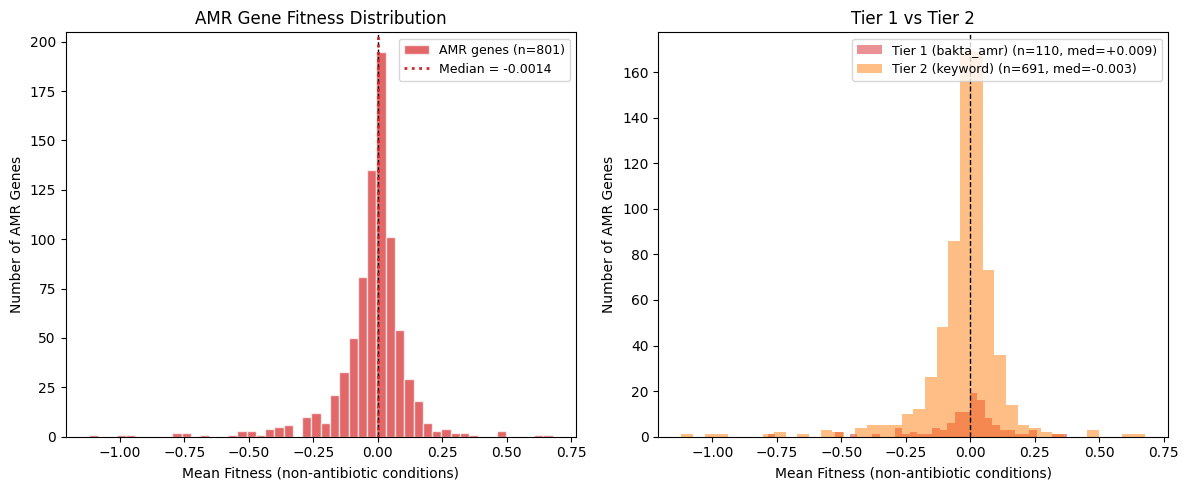

Saved to figures/amr_fitness_distribution.png


In [11]:
# Per-gene fitness distribution: AMR vs background (pooled across organisms)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: histogram of AMR gene mean fitness
ax = axes[0]
ax.hist(gene_df['mean_fitness'], bins=50, alpha=0.7, color='tab:red', edgecolor='white',
        label=f'AMR genes (n={len(gene_df)})')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(gene_df['mean_fitness'].median(), color='tab:red', linestyle=':', linewidth=2,
           label=f'Median = {gene_df["mean_fitness"].median():+.4f}')
ax.set_xlabel('Mean Fitness (non-antibiotic conditions)')
ax.set_ylabel('Number of AMR Genes')
ax.set_title('AMR Gene Fitness Distribution')
ax.legend(fontsize=9)

# Right: by tier
ax = axes[1]
for tier, color, label in [(1, 'tab:red', 'Tier 1 (bakta_amr)'),
                            (2, 'tab:orange', 'Tier 2 (keyword)')]:
    subset = gene_df[gene_df['amr_tier'] == tier]
    ax.hist(subset['mean_fitness'], bins=40, alpha=0.5, color=color,
            label=f'{label} (n={len(subset)}, med={subset["mean_fitness"].median():+.3f})')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Mean Fitness (non-antibiotic conditions)')
ax.set_ylabel('Number of AMR Genes')
ax.set_title('Tier 1 vs Tier 2')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'amr_fitness_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to figures/amr_fitness_distribution.png')

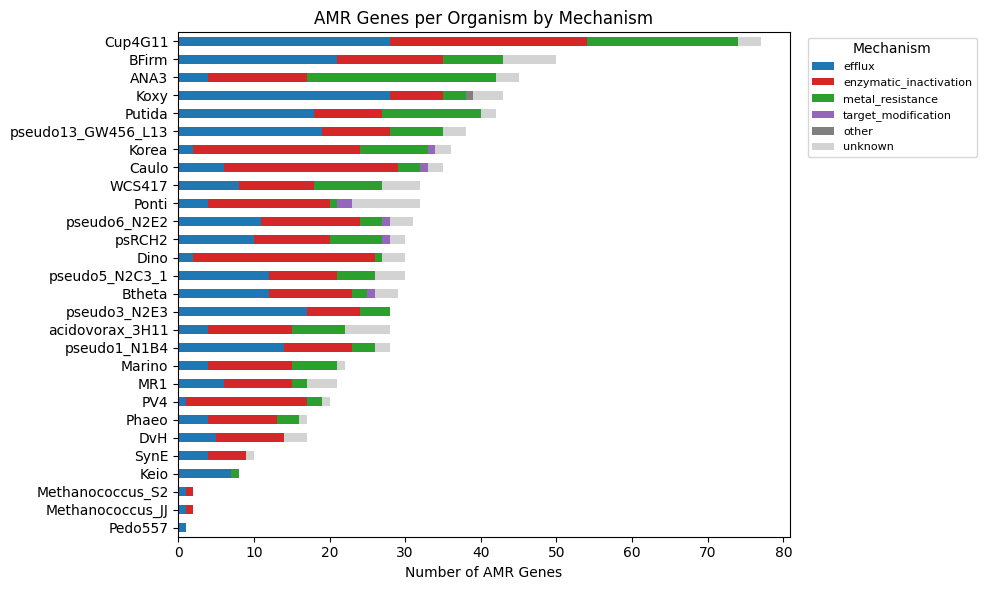

Saved to figures/amr_genes_per_organism.png


In [12]:
# AMR gene counts per organism, colored by mechanism
fig, ax = plt.subplots(figsize=(10, 6))

mech_order = ['efflux', 'enzymatic_inactivation', 'metal_resistance',
              'target_modification', 'other', 'unknown']
mech_colors = {'efflux': 'tab:blue', 'enzymatic_inactivation': 'tab:red',
               'metal_resistance': 'tab:green', 'target_modification': 'tab:purple',
               'other': 'tab:gray', 'unknown': 'lightgray'}

pivot = gene_df.groupby(['orgId', 'amr_mechanism']).size().unstack(fill_value=0)
# Reorder columns
pivot = pivot[[c for c in mech_order if c in pivot.columns]]
# Sort by total
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

pivot.plot(kind='barh', stacked=True, ax=ax,
           color=[mech_colors.get(c, 'gray') for c in pivot.columns])
ax.set_xlabel('Number of AMR Genes')
ax.set_ylabel('')
ax.set_title('AMR Genes per Organism by Mechanism')
ax.legend(title='Mechanism', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'amr_genes_per_organism.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to figures/amr_genes_per_organism.png')

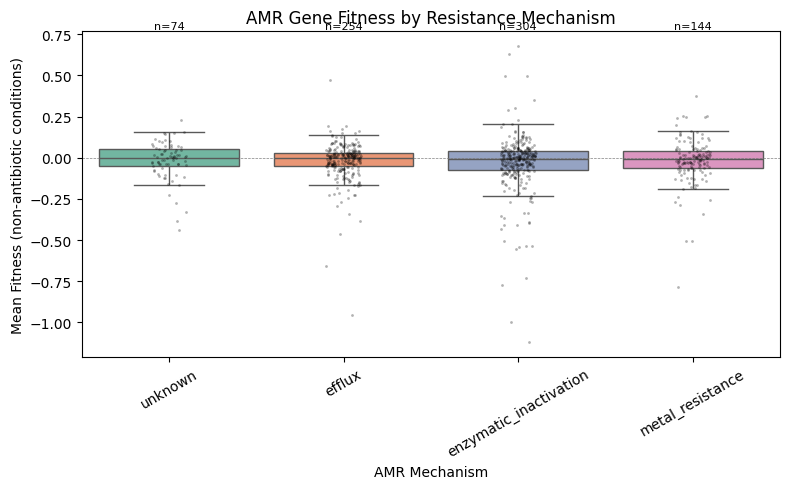

Saved to figures/fitness_by_mechanism_preview.png


In [13]:
# Fitness by mechanism (preview of H2)
fig, ax = plt.subplots(figsize=(8, 5))

# Only show mechanisms with >= 10 genes
mech_counts = gene_df['amr_mechanism'].value_counts()
plot_mechs = mech_counts[mech_counts >= 10].index.tolist()
plot_data = gene_df[gene_df['amr_mechanism'].isin(plot_mechs)]

order = plot_data.groupby('amr_mechanism')['mean_fitness'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_data, x='amr_mechanism', y='mean_fitness', order=order,
            palette='Set2', ax=ax, showfliers=False)
sns.stripplot(data=plot_data, x='amr_mechanism', y='mean_fitness', order=order,
              color='black', alpha=0.3, size=2, ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('AMR Mechanism')
ax.set_ylabel('Mean Fitness (non-antibiotic conditions)')
ax.set_title('AMR Gene Fitness by Resistance Mechanism')
ax.tick_params(axis='x', rotation=30)

# Add N labels
for i, mech in enumerate(order):
    n = len(plot_data[plot_data['amr_mechanism'] == mech])
    ax.text(i, ax.get_ylim()[1], f'n={n}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fitness_by_mechanism_preview.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to figures/fitness_by_mechanism_preview.png')

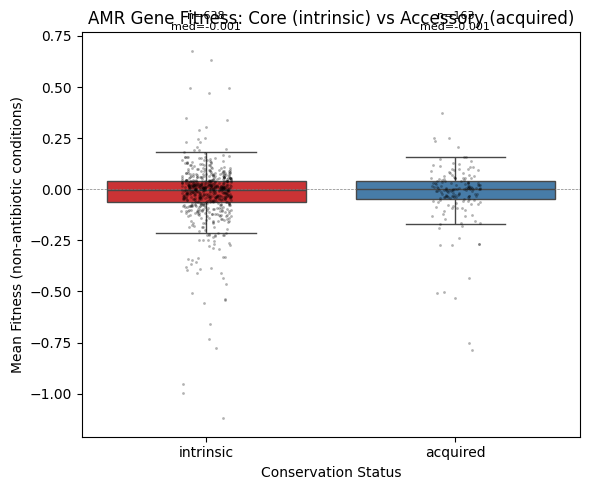

Saved to figures/fitness_core_vs_accessory_preview.png


In [14]:
# Fitness by conservation status (preview of H3)
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(data=gene_df, x='intrinsic_proxy', y='mean_fitness',
            palette='Set1', ax=ax, showfliers=False,
            order=['intrinsic', 'acquired'])
sns.stripplot(data=gene_df, x='intrinsic_proxy', y='mean_fitness',
              color='black', alpha=0.3, size=2, ax=ax,
              order=['intrinsic', 'acquired'])
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Conservation Status')
ax.set_ylabel('Mean Fitness (non-antibiotic conditions)')
ax.set_title('AMR Gene Fitness: Core (intrinsic) vs Accessory (acquired)')

for i, cat in enumerate(['intrinsic', 'acquired']):
    n = len(gene_df[gene_df['intrinsic_proxy'] == cat])
    med = gene_df[gene_df['intrinsic_proxy'] == cat]['mean_fitness'].median()
    ax.text(i, ax.get_ylim()[1], f'n={n}\nmed={med:+.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fitness_core_vs_accessory_preview.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to figures/fitness_core_vs_accessory_preview.png')

## 8. Save outputs

In [15]:
# Save per-gene fitness table
gene_df.to_csv(os.path.join(DATA, 'amr_fitness_noabx.csv'), index=False)
print(f'Saved {len(gene_df)} gene fitness values to data/amr_fitness_noabx.csv')

# Save per-organism effect sizes
mw_df.to_csv(os.path.join(DATA, 'organism_effect_sizes.csv'), index=False)
print(f'Saved {len(mw_df)} organism effect sizes to data/organism_effect_sizes.csv')

Saved 801 gene fitness values to data/amr_fitness_noabx.csv
Saved 25 organism effect sizes to data/organism_effect_sizes.csv


## 9. Checkpoint summary

Review these results before proceeding to NB03-04:

1. **Is there a detectable signal?** Check the meta-analysis pooled effect and CI.
2. **Does Tier 2 behave differently from Tier 1?** Check the sensitivity analysis.
3. **Are there enough matched antibiotic experiments for NB03?** Enumerate below.
4. **Does the effect size landscape suggest meaningful stratification?**

In [16]:
# Checkpoint: enumerate antibiotic-AMR class matches for NB03 planning
print('=== Antibiotic-AMR Class Matching for NB03 ===')
print()

# Map antibiotic classes used in experiment classification to AMR classes
ABX_TO_AMR_CLASS = {
    'beta_lactam': 'beta_lactam',
    'chloramphenicol': 'chloramphenicol',
    'tetracycline': 'tetracycline',
    'aminoglycoside': 'aminoglycoside',
    'glycopeptide': 'glycopeptide',
    'macrolide': 'macrolide_lincosamide',
    'fluoroquinolone': 'fluoroquinolone',
    'polymyxin': 'polymyxin',
    'other_antibiotic': None,  # no specific match
}

abx_exps = exps[exps['exp_category'] == 'antibiotic']

for abx_class, amr_class in sorted(ABX_TO_AMR_CLASS.items()):
    if amr_class is None:
        continue
    class_exps = abx_exps[abx_exps['antibiotic_class'] == abx_class]
    class_genes = gene_df[gene_df['amr_class'] == amr_class]
    
    if len(class_exps) == 0 and len(class_genes) == 0:
        continue
    
    # Find organisms with both
    orgs_with_exps = set(class_exps['orgId'])
    orgs_with_genes = set(class_genes['orgId'])
    orgs_both = orgs_with_exps & orgs_with_genes
    matched_genes = class_genes[class_genes['orgId'].isin(orgs_both)]
    
    testable = '  TESTABLE' if len(matched_genes) >= 5 and len(orgs_both) >= 1 else ''
    print(f'{abx_class:25s} -> {amr_class:25s}: '
          f'{len(class_exps):3d} exps, {len(class_genes):3d} genes, '
          f'{len(orgs_both):2d} shared orgs, {len(matched_genes):3d} matched genes{testable}')

print()
print('=== Decision point: review the above before proceeding to NB03 ===')

=== Antibiotic-AMR Class Matching for NB03 ===



aminoglycoside            -> aminoglycoside           :  70 exps,  54 genes, 14 shared orgs,  39 matched genes  TESTABLE
beta_lactam               -> beta_lactam              :  44 exps, 240 genes, 10 shared orgs, 105 matched genes  TESTABLE
chloramphenicol           -> chloramphenicol          :  51 exps,  10 genes,  6 shared orgs,   6 matched genes  TESTABLE
fluoroquinolone           -> fluoroquinolone          :  47 exps,   1 genes,  0 shared orgs,   0 matched genes
glycopeptide              -> glycopeptide             :  47 exps,   0 genes,  0 shared orgs,   0 matched genes
macrolide                 -> macrolide_lincosamide    :   0 exps,   5 genes,  0 shared orgs,   0 matched genes
polymyxin                 -> polymyxin                :  51 exps,   0 genes,  0 shared orgs,   0 matched genes
tetracycline              -> tetracycline             :  69 exps,   7 genes,  5 shared orgs,   7 matched genes  TESTABLE

=== Decision point: review the above before proceeding to NB03 ===
